## `distributions.ipynb`

This notebook plots different distribution and performance indices for HSC and DESI.

In [1]:
## Imports
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, match_coordinates_sky
from astropy.io import fits
from astropy.table import Table

USER_ROOT = Path('/global/cfs/cdirs/desicollab/users/jchdj')
USER_DATA = USER_ROOT / 'desi-y3-hsc' / 'data' / 'xmatch'
desi_f = USER_DATA / 'desi_xm_hsc_sep0_2.fits'
hsc_f = USER_DATA / 'hsc_xm_desi_sep0_2.fits'

In [2]:
desi = fio.FITS(desi_f)
hsc = fio.FITS(hsc_f)

Let's check the distributions and statistical properties of magnitude and redshift

Text(0.5, 1.0, 'HSC aperture mag distribution')

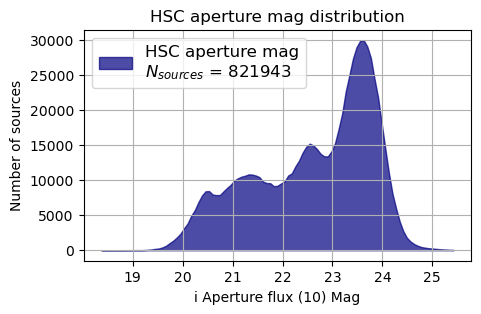

In [ ]:
# HSC aperture mag distribution

plt.figure(figsize=(5, 3))
apmag = hsc[1]['aperture_mag'].read()
count_hsc, bins_hsc = np.histogram(apmag, bins=np.linspace(min(apmag), max(apmag), 100))
plt.fill_between(bins_hsc[:-1], count_hsc, alpha=0.7, color='navy', label=f'HSC aperture mag\n' + r'$N_{sources}$' +f' = {len(apmag)}')
plt.grid()
plt.xlabel('i Aperture flux (10) Mag')
plt.ylabel('Number of sources')
plt.legend(loc='upper left', fontsize=12)
plt.title('HSC aperture mag distribution')

Text(0.5, 1.0, 'HSC / DESI z distribution')

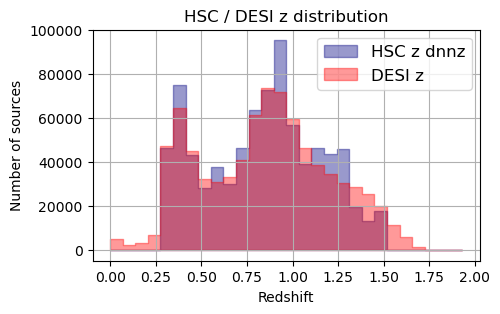

In [ ]:
# DESI / HSC z distribution

plt.figure(figsize=(5, 3))

z_hsc = hsc[1]['dnnz_photoz_best'].read()
zbins = np.linspace(0, 2, 30)
count_hsc, bins_hsc = np.histogram(z_hsc, bins=zbins)
plt.fill_between(bins_hsc[:-1], count_hsc, alpha=0.4, color='navy', label=f'HSC z dnnz', step='post')

z_desi = desi[1]['Z'].read()
count_desi, bins_desi = np.histogram(z_desi, bins=zbins)
plt.fill_between(bins_desi[:-1], count_desi, alpha=0.4, color='red', label=f'DESI z', step='post')

plt.grid()
plt.xlabel('Redshift')
plt.ylabel('Number of sources')
plt.legend(loc='upper right', fontsize=12)
plt.title('HSC / DESI z distribution')

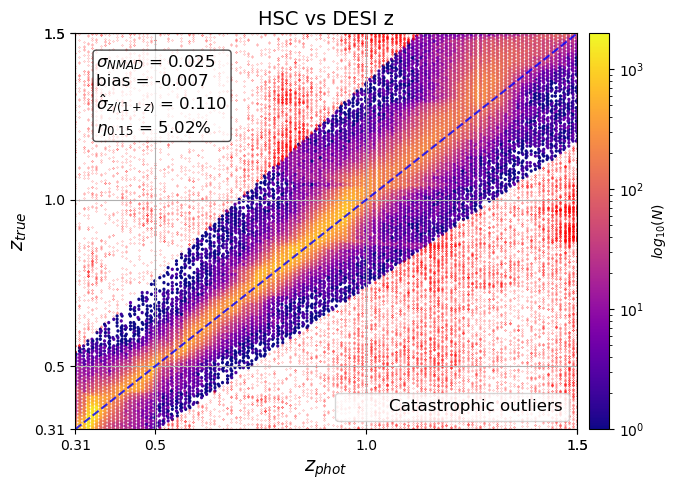

In [6]:
# HSC / DESI z comparison
z_phot = hsc[1]['dnnz_photoz_best'].read()
z_true = desi[1]['Z'].read()
cmap = plt.get_cmap('plasma')

plt.figure(figsize=(7, 5))

dz = z_phot - z_true
nmad = 1.4826 * np.median(np.abs(dz - np.median(dz))/(1 + z_true))
bias = np.median(dz/(1 + z_true))
nr = np.abs(dz)/(1 + z_true)
std = np.std(nr)
bool_out = nr > 0.15 #3*std
frac = np.sum(bool_out) / len(bool_out)

ztext = (
    r'$\sigma_{NMAD}$'
    + f' = {nmad:.3f}\nbias = {bias:.3f}\n' 
    + r'$\hat{\sigma}_{z/(1+z)}$' 
    + f' = {std:.3f}\n' + r'$\eta_{0.15}$' 
    + f' = {frac*100:.2f}%'
        )

plt.hexbin(z_phot[~bool_out], z_true[~bool_out], gridsize=300, cmap=cmap, bins='log', mincnt=1, label='')
plt.colorbar(label=r'$log_{10}(N)$', pad=0.02)
plt.scatter(z_phot[bool_out], z_true[bool_out], color='red', s=0.03, alpha=0.8, label='Catastrophic outliers')

plt.xlabel(r'$z_{phot}$', fontsize=14)
plt.ylabel(r'$z_{true}$', fontsize=14)
bds = [min(z_phot), max(z_phot)]
plt.ylim(bds[0], bds[1])
plt.xlim(bds[0], bds[1])
plt.plot(bds, bds, 'b--', alpha=0.8)
plt.yticks([bds[0], 0.5, 1, 1.5, bds[1]], labels=[bds[0], 0.5, 1.0, 1.5, bds[1]])
plt.xticks([bds[0], 0.5, 1, 1.5, bds[1]], labels=[bds[0], 0.5, 1.0, 1.5, bds[1]])


plt.text(
    bds[0]+0.05, 
    bds[1]-0.3, 
    ztext, 
    fontsize=12, 
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.2')
    )

plt.grid()
plt.title('HSC vs DESI z', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()